# DISRA Science Case Module

**NAME:** KBO_SURVEY

**GOAL:** How did the seeds of Solar System planets first come together?

**OBJECTIVE:** Discover Kuiper Belt Objects (KBOs) down to sizes that distinguish between different planetesimal formation scenarios.

**CODE PURPOSE:** Calculate the number of KBOs of various sizes discovered in an imaging survey with varying depth and sky coverage. The survey motivation is based on Signature Science Case #6 in the 2019 LUVOIR Final Report.

**BACKGROUND:**

Napier et al. (2024). "The DECam Ecliptic Exploration Project (DEEP). V. The Absolute Magnitude Distribution of the Cold Classical Kuiper Belt," PSJ, 5, 50

Sigma is the underlying KBO luminosity function, i.e., the number of objects per sq. degree as a function of r-band magnitude. Here we adopt three forms for sigma:

1. Rolling Power Law (Eq. 11)
2. Broken Power Law (Eq. 12)
3. Exponentially Tapered Power Law (Eq. 13)

and the best-fit parameters from the full DEEP sample of detected KBOs (Table 3). The exponentially tapered power law is predicted by streaming instability models of planetesimal formation and the rolling power law by models that produce a characteristic KBO size (e.g., turbulent concentration).

Description of LSST Solar System Deep Drill survey found here: https://community.lsst.org/t/deep-drilling-whitepapers/732
	  
**MODIFICATION HISTORY:**

[2024-05-08] Started by Aki Roberge (AR; aki.roberge@nasa.gov) in IDL

[2024-07-24] Translated to python by Breann Sitarski (BNS; breann.n.sitarski@nasa.gov)

[2024-10-12] Survey trade code completed by AR.

[2024-10-20] New camera ETC function (camera_exptime3) with variable telescope diameter added by BNS. Rewrite of survey trade code by AR.


# Setup

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
import scipy
import astropy.units as u
# from google.colab import files

In [2]:
!pip install hwo_disra

In [3]:
import astropy.units as u
from hwo_disra.api.notebook_api import DisraNBApi
from hwo_disra.EAC import create_syo_eac
from hwo_disra.Types import Time

api = DisraNBApi.get_instance()

# import os
# os.environ['PYSYN_CDBS'] = "/usr/local/lib/python3.10/dist-packages/syotools/pysynphot_data"
# os.environ['SCI_ENG_DIR'] = "/usr/local/lib/python3.10/dist-packages/syotools/sci_eng_interface/"

  points: [1136.3 1142.3 1142.4 1142.5 1152.7]
  lookup_table: [-9.31015728e-07 -2.34371190e-07 -2.17769838e-06 -1.89383420e-06
 -1.86404638e-07] [synphot.models]
  points: [1170.     1170.5    1171.3    ... 2241.1    2241.2001 2241.3   ]
  lookup_table: [-3.99896421e-07 -3.16809265e-06 -1.49050587e-06 ... -8.56435582e-07
 -9.55618745e-07 -4.15987490e-08] [synphot.models]
  points: [1180.5 1181.5 1241.5 1244.5 1248.5 1249.5 1262.5 1290.5 1307.5 1310.5
 1312.5 1315.5 1316.5 1317.5 1318.5 1321.5 1330.5 1333.5 1341.5 1342.5
 1343.5 1345.5 1346.5 1348.5 1352.5 1370.5 1372.5 1379.5 1380.5 1384.5
 1386.5 1387.5 1388.5 1389.5 1391.5 1395.5 1399.5 1400.5 1426.5 1427.5
 1428.5 1429.5 1434.5 1447.5 1448.5 1449.5 1450.5 1454.5 1455.5 1456.5
 1461.5 1466.5 1474.5 1475.5 1482.5 1493.5 1498.5 1505.5 1519.5 1539.5
 1558.5 1563.5 1567.5 1569.5 1570.5 1575.5 1577.5 1579.5 1581.5 1582.5
 1584.5 1589.5 1590.5 1591.5 1592.5 1594.5 1595.5 1596.5 1599.5 1600.5
 1601.5 1605.5 1606.5 1607.5 1608.5 1609.5 1612

# Definition of Functions

In [4]:
def rolling(m):
  """
  Rolling power law for the KBO luminosity function (Napier et al. 2024, Eq. 11).

  Args:
    m: array of R band apparent magnitudes

  Returns: number of KBOs per sq. degree as function of R band magnitude
  """
  sigma_23 = 0.28     # number of objects with m_r = 23 per sq. degree
  alpha1_roll = 0.89
  alpha2_roll = -0.07

  sigma_roll = sigma_23 * 10**( alpha1_roll*(m-23.0) + alpha2_roll*(m-23.0)**2.0 )
  return sigma_roll   # Number of KBOs per sq. degree as function of R band magnitude

In [5]:
def broken(m):
  """
  Broken power law for the KBO luminosity function (Napier et al. 2024, Eq. 12).

  Args:
    m: array of R band apparent magnitudes

  Returns: number of KBOs per sq. degree as function of R band magnitude
  """
  alpha1_broken = 0.90	# bright end slope
  alpha2_broken = 0.49	# faint end slope
  m0_broken = 23.59	    # normalization parameter
  mB_broken = 24.59	    # magnitude at which break occurs

  a = np.where(m < mB_broken)[0]
  b = np.where(m >= mB_broken)[0]

  sigma_brokenA = 10**( alpha1_broken*(m[a]-m0_broken) )
  sigma_brokenB = 10**( alpha2_broken*(m[b]-m0_broken) + (alpha1_broken-alpha2_broken)*(mB_broken-m0_broken) )

  sigma_broken = np.concatenate((sigma_brokenA, sigma_brokenB)) # should we concatenate these?
  return sigma_broken

In [6]:
def taper(m):
  """
  Exponentially Tapered power law for the KBO luminosity function (Napier et al. 2024, Eq. 13).

  Args:
    m: array of R band apparent magnitudes

  Returns: number of KBOs per sq. degree as function of R band magnitude
  """
  alpha_taper = 0.21	# faint-end power-law slope
  beta_taper = 0.14	  # strength of exponential taper
  m0_taper = 13.95    # normalization parameter
  mB_taper = 28.74    # magnitude at which exponential taper begins to dominate

  sigma_taper = np.exp( -10**( beta_taper*(mB_taper-m) ) ) * ( 10**( (alpha_taper-beta_taper)*m - (m0_taper*alpha_taper) ) ) * ( alpha_taper*10**(m*beta_taper) + beta_taper*10**(mB_taper*beta_taper) )
  return sigma_taper

In [7]:
def mag_to_km(m):
  """
  Convert R band magnitude to KBO diameter.

  Args:
    m: array of R band apparent magnitudes

  Returns: array of KBO diameters in km
  """
  dia_ref = 2.0 	# Reference diameter (km)
  ref_mag = 33.0 	# Reference R magnitude for 2-km body at 40 AU from Bekki Dawson
  KBO_dia = dia_ref * 10**(-0.2*(m - ref_mag))
  return KBO_dia    # KBO diameter in km

In [8]:
def km_to_mag(KBO_dia):
  """
  Convert KBO diameter to R band magnitude.

  Args:
    m: array of KBO diameters in km

  Returns: array of R band apparent magnitudes
  """
  dia_ref = 2.0 	# Reference diameter (km)
  ref_mag = 33.0 	# Reference R magnitude for 2-km body at 40 AU from Bekki Dawson
  m =  ref_mag - 5.0 * np.log10(KBO_dia/dia_ref)
  return m    # R band magnitude

In [9]:
import numpy as np
seed_rng = np.random.default_rng(170348551358309681728636926940661406127)

def addnoise(y):
  """
  Simple routine to produce a noisy 1-D array (e.g., smooth function -> scattered points).

  Args:
    y: 1-D array

  Returns: 1-D array drawn from y assuming the uncertainty on each y value is normally distributed

  """
  rng = np.random.default_rng(seed = int.from_bytes(seed_rng.bytes(16)))
  fake = [0]*len(y)
  for i in range(len(y)):
    fake[i] = y[i] + rng.normal()*np.sqrt(y[i])
  return fake

In [10]:
def idl_tabulate(x, f, p=5):
  """
  Integrates a tabulated set of data {Xi,Fi} on the closed interval [min(X), max(X)], using a five-point Newton-Cotes integration formula.

  Modeled on the IDL int_tabulated function.

  Args:
    x: 1-D array with the independent variable values
    f: 1-D array with the function values to be integrated
    p (optional): degree of the Newton-Cotes formula (default = 5)

  Returns: Single value for the area under the curve represented by the function
  """
  def newton_cotes(x, f):
    if x.shape[0] < 2:
      return 0
      rn = (x.shape[0] - 1) * (x - x[0]) / (x[-1] - x[0])
      weights = scipy.integrate.newton_cotes(rn)[0]
      return (x[-1] - x[0]) / (x.shape[0] - 1) * np.dot(weights, f)
  ret = 0
  for idx in range(0, x.shape[0], p - 1) :
      ret += newton_cotes(x[idx:idx + p], f[idx:idx + p])
  return ret

In [11]:
def lum_funct_plot(m, omega = 1.0, points1 = [1], points2=[1], filename=''):
  """
  Plots three different KBO luminosity functions.

  Args:
    m: array of R band magnitudes
    omega (optional): sky coverage in square degrees (default = 1.0)
    points1 (optional): 1-D array of numbers of KBOs to be overplotted as points
    points2 (optional): Another 1-D array of numbers of KBOs to be overplotted as points
    filename (optional): name of file to save plot to (default = '')

  Returns: Plot with numbers of KBOs in a solid angle (y-axis) vs. KBO diameter (x-axis)
  """
  # m = array of R band magnitudes
  # omega = sky coverage in square degrees
  KBO_dia = mag_to_km(m)
  sigma_broken = broken(m)*omega
  sigma_roll = rolling(m)*omega
  sigma_taper = taper(m)*omega

  fig = plt.figure(figsize=(9,5))
  ax1 = fig.add_subplot(111)

  ax1.loglog(KBO_dia, sigma_broken)
  plt.xlim([np.max(KBO_dia), np.min(KBO_dia)])
  plt.ylim([np.min(sigma_broken), np.max(sigma_broken)])
  ax1.set_ylabel('N(m$_{r}$) in '+str(round(omega,3))+' deg$^{2}$')
  ax1.set_xlabel('KBO Diameter (km)')
  ax1.xaxis.set_major_formatter('{x}')

  r = np.nonzero(m >= 25.92)[0]
  s = np.nonzero(m >= 26.65)[0]
  ax1.axvspan(KBO_dia[r[0]], KBO_dia[s[0]], color = 'lightgray')
  ref = np.median(sigma_broken)
  ax1.text((KBO_dia[s[0]] + KBO_dia[r[0]])/2., ref*2.0, 'DEEP Survey Limits', color = 'black', horizontalalignment = 'center')
  q = np.nonzero(m >= 28)[0]
  ax1.axvline(x = KBO_dia[q[0]], color = 'darkgray')
  ax1.text(KBO_dia[q[0]], ref*0.008, 'LSST Deep Drill', color = 'black', horizontalalignment = 'center')

  ax1.fill_between(KBO_dia, sigma_broken + np.sqrt(sigma_broken), sigma_broken - np.sqrt(sigma_broken), alpha=0.2, color = 'gold')
  ax1.fill_between(KBO_dia, sigma_roll + np.sqrt(sigma_roll), sigma_roll - np.sqrt(sigma_roll), alpha=0.2, color = 'blue')
  ax1.fill_between(KBO_dia, sigma_taper + np.sqrt(sigma_taper), sigma_taper - np.sqrt(sigma_taper), alpha=0.2, color = 'magenta')

  if len(points1) == len(m):
    ax1.plot(KBO_dia, points1, 'o', color = 'red', markersize=1)
  if len(points2) == len(m):
    ax1.plot(KBO_dia, points2, 'o', color = 'blue', markersize=1)
  ax1.plot(KBO_dia, sigma_taper, color = 'red', label = 'Exponentially Tapered Power Law')
  ax1.plot(KBO_dia, sigma_roll, color = 'blue', label = 'Rolling Power Law')
  ax1.plot(KBO_dia, sigma_broken, color = 'darkgoldenrod', label = 'Broken Power Law')
  ax1.legend(title = 'KBO Luminosity Functions', alignment='left', loc = 'upper left')

  ax2 = ax1.twiny()
  axis_d_range = ax1.get_xlim()
  axis_m_range = km_to_mag(np.array(axis_d_range))
  axis_m = np.arange(axis_m_range[0], axis_m_range[1]+1, 1)
  axis_d = mag_to_km(axis_m)
  ax2.set_xscale('log')
  ax2.set_xlim(np.max(axis_d), np.min(axis_d))
  ax2.get_xaxis().set_tick_params(which='minor', size=0)
  ax2.set_xticks(axis_d, labels=[str(x) for x in axis_m])
  ax2.set_xlabel('Apparent R-Band Magnitude')
  if filename != '':
    plt.savefig(filename, bbox_inches='tight')
    # files.download(filename)
  plt.show()

In [12]:
def cont_plot(depth, omega, matrix, num_levels=20, c_levels=[1-0.9973, 1 - 0.95], c_color='white', bar_label='p-value', title='', filename=''):
  """
  Makes a contour plot

  Args:
    depth: array of R band magnitudes (length: n)
    omega: sky coverage in square degrees (length: m)
    matrix: 2-D array of values with dimensions m x n
    num_levels (optional): number of contour levels (default = 20)
    c_levels (optional): values for overplotted countour lines (default = [1-0.9973, 1 - 0.95])
    c_color (optional): color of contour lines (default = 'white')
    bar_label (optional): text label for colorbar
    title (optional): text title overlaid on ploted image (default = ' ')

  Returns: Produces plot with countours of matrix values and returns the contour levels
  """
  fig = plt.figure(figsize=(9,5))
  ax = fig.add_subplot(111)
  ax.set_xlabel('Survey Sky Coverage (deg$^{2}$)')
  ax.set_ylabel('Survey Depth (R mag limit)')
  cont = ax.contourf(omega, depth, matrix, levels=num_levels)
  cont_lines = ax.contour(omega, depth, matrix, levels=c_levels, colors=c_color)
  ax.clabel(cont_lines, inline=True, fontsize='medium')
  fig.colorbar(cont, label=bar_label)
  x = np.max(omega) - (np.max(omega) - np.min(omega))*0.05
  y = np.max(depth) - (np.max(depth) - np.min(depth))*0.05
  ax.text(x, y, title, color = 'white', horizontalalignment = 'right', verticalalignment = 'top', fontsize='medium', fontweight='semibold')
  if filename != '':
    plt.savefig(filename, bbox_inches='tight')
    # files.download(filename)
  plt.show()
  return cont.levels

In [13]:
from syotools.models import SourcePhotometricExposure

from syotools.models import Source


def camera_exptime3(telescope, template, mag, snr_goal, diameter=6.0, silent=False):

    ''' Run a basic SNR calculation that takes in a telescope,
      spectral template, normalization magnitude, and SNR goal
      to compute exptime. For converting magnitude, template,
      and exptime to SNR, use camera_snr.py

        usage:
          exptime, hri = camera_exptime(telescope, template, mag, snr_goal, diameter=diameter, silent=False)

          positional arguments:

           1-telescope = 'EAC1', 'EAC2', or 'EAC3'. This argument is a string.
             EAC1 = 6 m inner diameter, 7.2 outer diameter hex pattern, off-axis
             EAC2 = 6 m diameter off-axis
             EAC3 = 8 m diameter on-axis

           2-template = your choice of spectral template:
               'Classical T Tauri', 'M1 Dwarf', 'G Dwarf', '10 Myr Starburst', 'QSO',
               'Seyfert 1', 'Seyfert 2', 'Liner', 'O5V Star', 'G2V Star', 'Orion Nebula',
               'G191B2B (WD)', 'GD71 (WD)', 'GD153 (WD)', 'Starburst, No Dust',
               'Starburst, E(B-V) = 0.6', 'B5V Star', 'M2V Sta', 'Elliptical Galaxy',
               'Sbc Galaxy', 'Starburst Galaxy', 'NGC 1068', 'Galaxy with f_esc, HI=1, HeI=1',
               'Galaxy with f_esc, HI=0.001, HeI=1', 'Blackbody5000', 'Blackbody100000'

           3-mag = V magnitude to normalize the template spectrum, a float.

           4-snr_goal = desired SNR, per pixel, for each band

           outputs are arrays with the SNR in each band for FUV, NUV, U, B, V, R, I, J, H, K
       '''

    from syotools.models import Telescope, Camera

    # create a Telescope, Camera, and Exposure
    tel, hri = Telescope(), Camera()
    tel.set_from_sei(telescope)
    tel.effective_aperture = diameter * u.meter
    hri.set_from_sei('HRI')
    tel.add_camera(hri)

    source = Source()
    redshift = 0. # changes to these are not implemented yet
    extinction = 0.

    source.set_sed(template, mag, redshift, extinction, bandpass="johnson,v")

    exp = SourcePhotometricExposure()
    exp.source = source
    hri.add_exposure(exp)

    exp._snr = [snr_goal] * u.Unit('electron(1/2)')
    exp.unknown = 'exptime'
    hri_exptime = exp.recover('exptime')

    if not silent:
        for bb, ee in zip(hri.bandnames, hri_exptime):
            print("{}, exptime = {}".format(bb, ee))

    return hri_exptime, hri

# Plot of KBO luminosity functions
For inclusion in Science Case Development Document (SCDD)

X-axis: KBO diameter

Y-axis: Number of KBOs per sq. deg

In [14]:
m = np.arange(1101)*0.01 + 22.0  # R band apparent magnitude

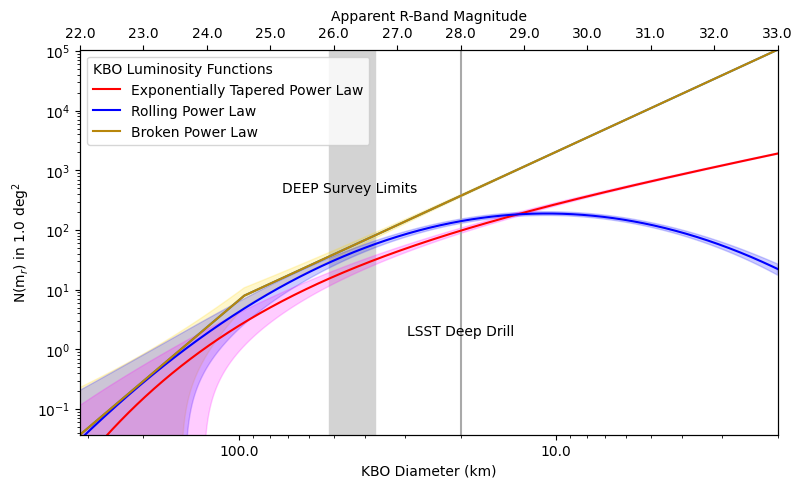

In [15]:
lum_funct_plot(m, filename='kbo_lum-funct.pdf')

# Science Return vs. Observation Quality (Panel 1)

**PHYSICAL PARAMETERS:** Determine whether the true KBO luminosity function is represented by an Exponential Tapered Power Law or a Rolling Power Law at 95% confidence.

**OBSERVATIONS:** R band imaging survey with depth $(\mathrm{R_{lim}})$ and sky coverage $(\Omega)$ sufficient to detect enough KBOs.

**METHOD:** For different pairs of $\mathrm{R_{lim}}$ and $\Omega$, simulate numbers of KBOs assuming the two luminosity functions. Use the two-sample Kolmogorov-Smirnov test to determine the probability that the two simulated datasets are drawn from the same distribution.

**RESULT:** Pairs of survey depth and sky coverage values that produce simulated datasets with less than 5% probability of being drawn from the same distribution.

**Illustrative plot**

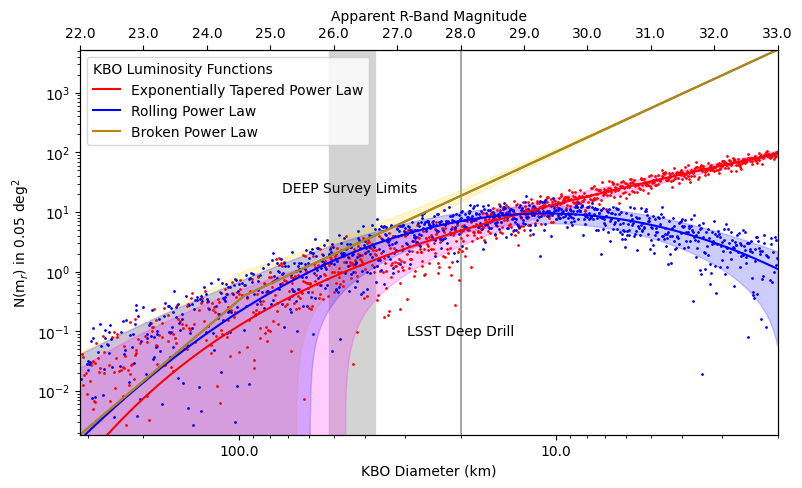

In [16]:
sigma_taper = taper(m)
sigma_roll = rolling(m)
omega = 0.05  # Sky coverage in sq. degrees
points_taper = addnoise(sigma_taper*omega)
points_roll = addnoise(sigma_roll*omega)
lum_funct_plot(m, omega=omega, points1=points_taper, points2=points_roll)

**Simulate surveys and test for goodness**

In [17]:
# Ranges of depth and sky coverage to test
survey_depth = np.arange(36)*0.20 + 26.0    # R band apparent magnitude
survey_omega = np.arange(41)*0.0005         # Survey area in sq. deg.

In [18]:
ks_matrix = None
# try:
#   with open("nb_ks_matrix.pickle", "rb") as f:
#     ks_matrix = pickle.load(f)
# except Exception as e:
#   pass

api = DisraNBApi.get_instance()

# Simulate datasets and compare with K-S test. Repeat to smooth out stochastic
# behavior.
if ks_matrix is None:
  ks_matrix = np.zeros(shape=(len(survey_depth),len(survey_omega)))
  tests = api.get_parameter('tests', default = 50) # Should actually iterate to convergence
  for k in range(tests):
    for i in range(len(survey_depth)):
      a = np.nonzero(m <= survey_depth[i])[0]
      for j in range(len(survey_omega)):
        points_taper = addnoise(sigma_taper[a]*survey_omega[j])
        points_roll = addnoise(sigma_roll[a]*survey_omega[j])
        res = scipy.stats.ks_2samp(points_taper, points_roll, alternative='two-sided')
        ks_matrix[i,j] = ks_matrix[i,j] + res[1]
  ks_matrix = ks_matrix/tests

{}


In [19]:
# import pickle
# with open("nb_ks_matrix.pickle", "wb") as f:
#     pickle.dump(ks_matrix, f)

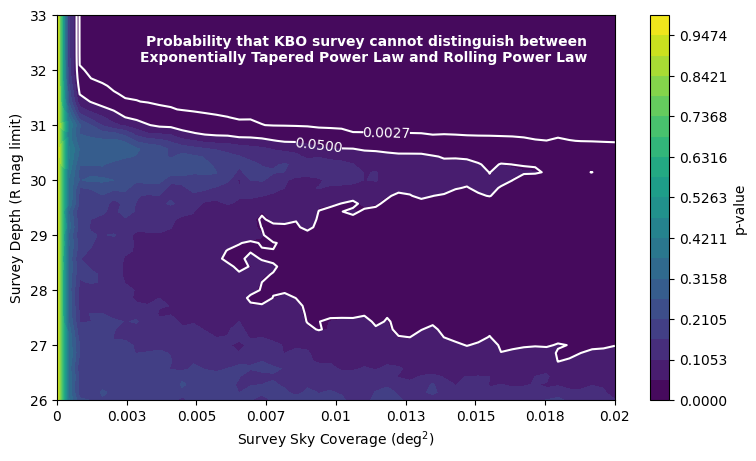

In [20]:
from hwo_disra.Types import ScienceYield
from hwo_disra.Types import ScienceValue

yieldinator = api.matrix_lookup_yieldinator(survey_depth, survey_omega, ks_matrix,
                                            variable_x='magnitude', variable_y='sky_coverage',
                                            yield_units = 'p-value',
                                            thresholds = {ScienceValue.ENHANCING: ScienceYield(1 - 0.95),
                                                          ScienceValue.ENABLING: ScienceYield(1 - 0.9973)})

eval_results = api.evaluate(yieldinator, register=True)

api.contour_plot_yield(eval_results, x_key ='sky_coverage', y_key ='magnitude', z_key ='yield',
                       contour_levels=sorted(yieldinator.thresholds().values()),
                       figsize = (9, 5),
                       axis_labels = {'yield': 'p-value', 'sky_coverage': 'Survey Sky Coverage (deg$^{2}$)',
                                            'magnitude': 'Survey Depth (R mag limit)'},
                       titles = ['Probability that KBO survey cannot distinguish between\nExponentially Tapered Power Law and Rolling Power Law'])

# levels = cont_plot(depth=survey_depth, omega=survey_omega, matrix=ks_matrix,
#                    title = 'Probability that KBO survey cannot distinguish between\nExponentially Tapered Power Law and Rolling Power Law')

**FINDING:** Confidence contours show complex and variable structure below R $\sim 31$ due to the crossing of the two power laws. This complexity indicates we want 99.7% ($3 \sigma$) probability rather than 95% ($2 \sigma$).

**Extract acceptable surveys**

In [21]:
# "Enhancing" = survey can distinguish between two power laws at 95% confidence
conf1 = 1.0 - 0.95
good_ks = np.where(ks_matrix <= conf1, ks_matrix, float('nan'))
q = np.where(ks_matrix <= conf1)
good_depth = survey_depth[q[0]]
good_omega = survey_omega[q[1]]

In [22]:
# "Enabling" = survey can distinguish between two power laws at 99.7% confidence
conf2 = 1.0 - 0.997
very_good_ks = np.where(ks_matrix <= conf2, ks_matrix, float('nan'))
q = np.where(ks_matrix <= conf2)
very_good_depth = survey_depth[q[0]]
very_good_omega = survey_omega[q[1]]

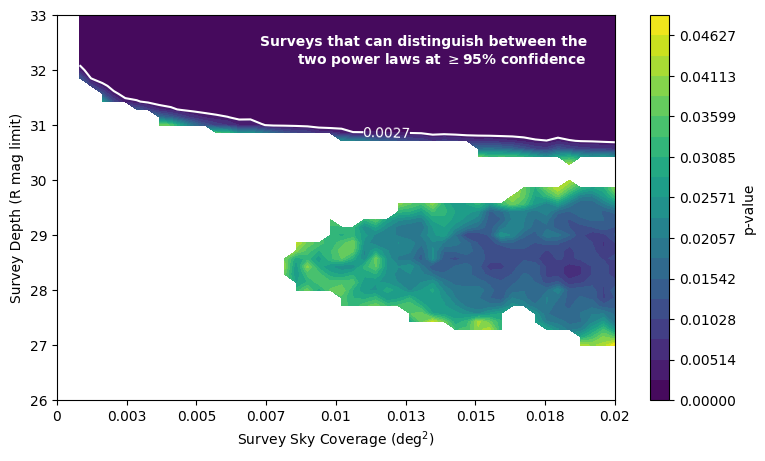

In [23]:
good_ks_yieldinator = api.matrix_lookup_yieldinator(survey_depth, survey_omega, good_ks,
                                                    variable_x='magnitude', variable_y='sky_coverage',
                                                    thresholds = {ScienceValue.ENHANCING: ScienceYield(1 - 0.95),
                                                                  ScienceValue.ENABLING: ScienceYield(1 - 0.9973)},
                                                    yield_units = 'p-value')
results = api.evaluate(good_ks_yieldinator, register=False)
api.contour_plot_yield(results, x_key ='sky_coverage', y_key ='magnitude', z_key ='yield',
                       contour_levels=sorted(yieldinator.thresholds().values()),
                       axis_labels = {'yield': 'p-value', 'sky_coverage': 'Survey Sky Coverage (deg$^{2}$)',
                                            'magnitude': 'Survey Depth (R mag limit)'},
                       titles = ['Surveys that can distinguish between the\ntwo power laws at $\\geq$95% confidence'],
                       figsize = (9, 5))

# levels = cont_plot(survey_depth, survey_omega, good_ks, title = 'Surveys that can distinguish between the\ntwo power laws at $\\geq$95% confidence',
#                    filename='kbo_panel1_plot1.pdf')

**Plot showing enabling HWO Surveys, enhancing surveys, and state-of-the-art**

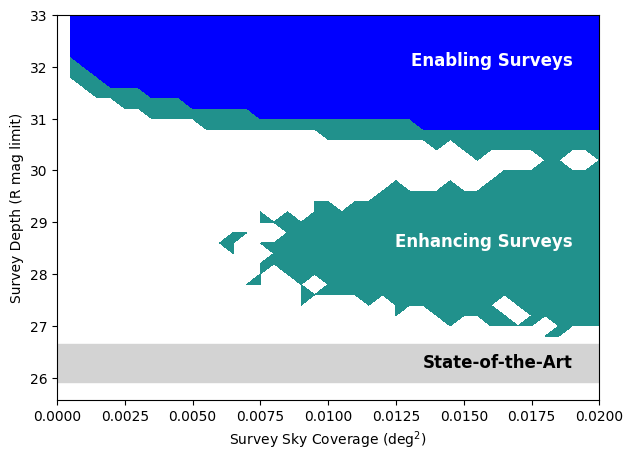

In [24]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111)
ax.set_xlabel('Survey Sky Coverage (deg$^{2}$)')
ax.set_ylabel('Survey Depth (R mag limit)')
cont95 = ax.contourf(survey_omega, survey_depth, good_ks, levels=[0.0, 1 - conf1])
cont99 = ax.contourf(survey_omega, survey_depth, very_good_ks, colors = ['blue'], levels=[0.0, 1 - conf2])
x1 = np.max(survey_omega) - (np.max(survey_omega) - np.min(survey_omega))*0.05
y1 = np.max(survey_depth) - (np.max(survey_depth) - np.min(survey_depth))*0.60
title1='Enhancing Surveys'
ax.text(x1, y1, title1, color = 'white', horizontalalignment = 'right', verticalalignment = 'top', fontsize='large', fontweight='semibold')
y2 = np.max(survey_depth) - (np.max(survey_depth) - np.min(survey_depth))*0.10
title2='Enabling Surveys'
ax.text(x1, y2, title2, color = 'white', horizontalalignment = 'right', verticalalignment = 'top', fontsize='large', fontweight='semibold')
ax.axhspan(25.92, 26.65, color='lightgrey')
y3 = np.max(survey_depth) - (np.max(survey_depth) - np.min(survey_depth))*0.93
title3='State-of-the-Art'
# DEEP survey magnitude limits
ax.text(x1, (26.65 - 25.92)/2. + 25.92, title3, color = 'black', horizontalalignment = 'right', verticalalignment = 'center', fontsize='large', fontweight='semibold')
plt.savefig("kbo_panel1_plot2.pdf", bbox_inches='tight')
# files.download("kbo_panel1_plot2.pdf")
plt.show()

# How do the exposure times scale with telescope aperture as a function of magnitude?

In [25]:
SNR = 5.0                           # SNR goal
Rband_index = 5                     # Location of R band exposure time in output of camera ETC
diameters = [2.4, 4, 5, 6, 7, 8]    # Range of telescope diameters in m

In [ ]:
import warnings

exp_time_at_snr = api.exptime_from_magnitude_fun(snr_goal=SNR, rband_index=Rband_index)

def compute_time(eac, yield_value, magnitude, sky_coverage) -> Time:
  # TODO: Once we're on the SEI yaml read this from there.
  camera_fov = (2.0*3.0)/(60*60.)   # HRI field-of-view in sq. deg.
  nvisits = np.ceil(sky_coverage/camera_fov)
  one_visit = exp_time_at_snr(eac, magnitude)
  return Time(one_visit * nvisits)
timeinator = api.timeinator(yieldinator, timeinate=compute_time)
warnings.filterwarnings("ignore", message="divide by zero encountered in log")

def time_transform(time, yield_result):
  if yield_result <= 1 - 0.95:
    return time / (24.0 * 60 * 60)
  else:
    return float("nan")
evaluations = api.evaluate(timeinator, steps = 20, register=True)

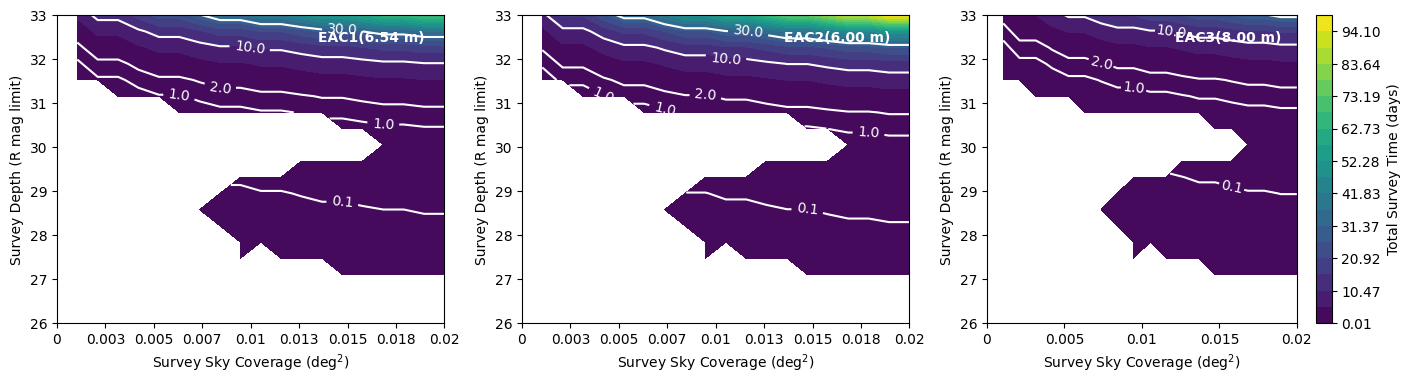

In [ ]:
api.eac_panels(evaluations, 'sky_coverage', 'magnitude', 'time',
               figsize=(17, 4),
               contour_levels=[0.1, 1.0, 2.0, 10.0, 30.0],
               transforms={'time': time_transform},
               axis_labels={'sky_coverage': "Survey Sky Coverage (deg$^{2}$)",
                            'magnitude': "Survey Depth (R mag limit)",
                            'time': "Total Survey Time (days)"})


In [ ]:
# Calculate image exposure times as function of magnitude for different aperture sizes
exponent_array = np.zeros(len(survey_depth))
for i in range(len(survey_depth)):
  # for j in range(1, len(diameters)):
  exptime, hri = camera_exptime3('EAC2', 'G2V Star', survey_depth[i], SNR, diameter=diameters[0], silent=True)
  t_ref = np.array(exptime[Rband_index])
  D_ref = diameters[0]
  exptime, hri = camera_exptime3('EAC2', 'G2V Star', survey_depth[i], SNR, diameter=diameters[-1], silent=True)
  t_ratio = np.array(exptime[Rband_index])/t_ref
  exponent = math.log(t_ratio, D_ref/diameters[-1])
  exponent_array[i] = exponent

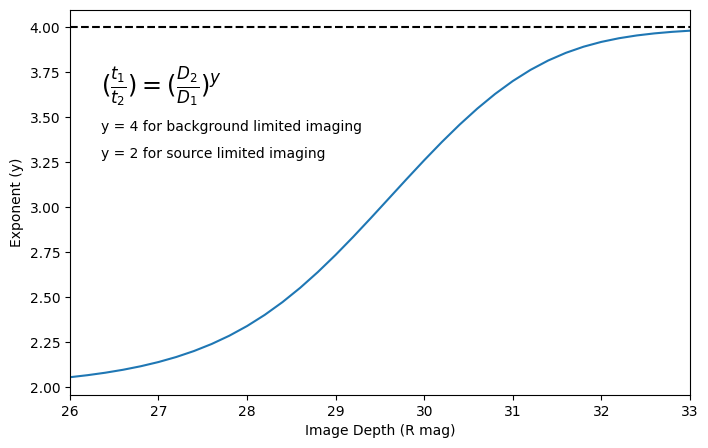

In [ ]:
fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(111)
plt.plot(survey_depth, exponent_array)
plt.plot(survey_depth, np.ones(len(survey_depth))*4, linestyle='dashed', color='black')
plt.xlim([np.min(survey_depth), np.max(survey_depth)])
ax1.set_xlabel('Image Depth (R mag)')
ax1.set_ylabel('Exponent (y)')
x = np.min(survey_depth) + (np.max(survey_depth) - np.min(survey_depth))*0.05
y = np.max(exponent_array) - (np.max(exponent_array) - np.min(exponent_array))*0.1
ax1.text(x,y,'$(\\frac{t_{1}}{t_{2}}) = (\\frac{D_{2}}{D_{1}})^{y}$', color = 'black', horizontalalignment = 'left', verticalalignment = 'top', fontsize='xx-large')
ax1.text(x,y*0.92,'y = 4 for background limited imaging', color = 'black', horizontalalignment = 'left', verticalalignment = 'top', fontsize='medium')
ax1.text(x,y*0.88,'y = 2 for source limited imaging', color = 'black', horizontalalignment = 'left', verticalalignment = 'top', fontsize='medium')
plt.savefig("time_scaling.pdf", bbox_inches='tight')
# files.download("time_scaling.pdf")
plt.show()

**FINDING:** Exposure times are significantly affected by background for all R magnitudes of interest. Do not scale exposure times by $D^{-2}$ !

# Observation Quality vs. Observatory Capability (Panel 2)

**Plot 1: Survey Quality vs. Total Survey Time**
*   SNR goal = 5
*   Assume fixed observatory parameters from EAC2

In [ ]:
camera_fov = (2.0*3.0)/(60*60.)   # HRI field-of-view in sq. deg. TO DO: Read from .yaml file
overhead = 120.0                  # Overhead per visit in seconds (WAG)

In [ ]:
image_time_matrix = np.copy(good_ks)
survey_time_matrix_o = np.copy(good_ks)
for i in range(len(survey_depth)):
  exptime, hri = camera_exptime3('EAC2', 'G2V Star', survey_depth[i], SNR, silent=True)  # Exposure time per image in seconds
  for j in range(len(survey_omega)):
    visits = np.ceil(survey_omega[j]/camera_fov)                                    # Number of images to cover omega
    image_time_matrix[i,j] = (np.array(exptime[Rband_index]))/(24.0*60.0*60.0)                              # Time per R band image in days
    survey_time_matrix_o[i,j] = (np.array(visits*exptime[Rband_index]) + visits*overhead)/(24.0*60.0*60.0)  # Total time for all R band images in days with per visit overheads

In [ ]:
good_time = np.where(good_ks >= 0.0, survey_time_matrix_o, float('nan'))

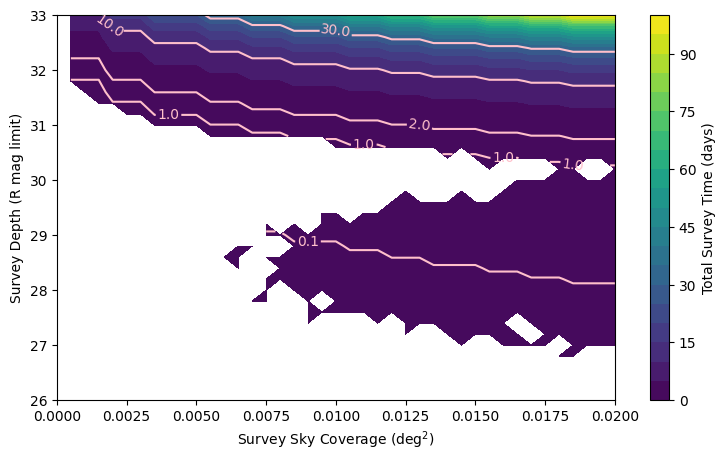

In [ ]:
good_levels = cont_plot(survey_depth, survey_omega, good_time, c_levels = [0.1, 1.0, 2, 10, 30], c_color = 'pink', bar_label = 'Total Survey Time (days)',
                        filename='kbo_panel2_plot1.pdf')

**Plot 2: Survey Quality vs. Telescope Diameter**

In [ ]:
image_time_matrix_D = np.zeros((len(diameters), len(survey_depth), len(survey_omega)))
survey_time_matrix_o_D = np.zeros((len(diameters), len(survey_depth), len(survey_omega)))

In [ ]:
for i in range(len(diameters)):
  for j in range(len(survey_depth)):
    exptime, hri = camera_exptime3('EAC2', 'G2V Star', survey_depth[j], SNR, diameter=diameters[i], silent=True) # Exposure time per image in seconds
    for k in range(len(survey_omega)):
      visits = np.ceil(survey_omega[k]/camera_fov)                                                      # Number of images to cover omega
      image_time_matrix_D[i,j,k] = (np.array(exptime[Rband_index]))/(24.0*60.0*60.0)                              # Time per R band image in days
      survey_time_matrix_o_D[i,j,k] = (np.array(visits*exptime[Rband_index]) + visits*overhead)/(24.0*60.0*60.0)  # Total time for all R band images in days with per visit overheads

In [ ]:
# Get contour levels to use for all plots
fig = plt.figure()
ax = fig.add_subplot(111)
i = np.where(diameters == np.max(diameters))[0][0]
times_D = np.where(good_ks >= 0.0, survey_time_matrix_o_D[i], float('nan'))
cont = ax.contourf(survey_omega, survey_depth, times_D)
levels_D = cont.levels
plt.close(fig)

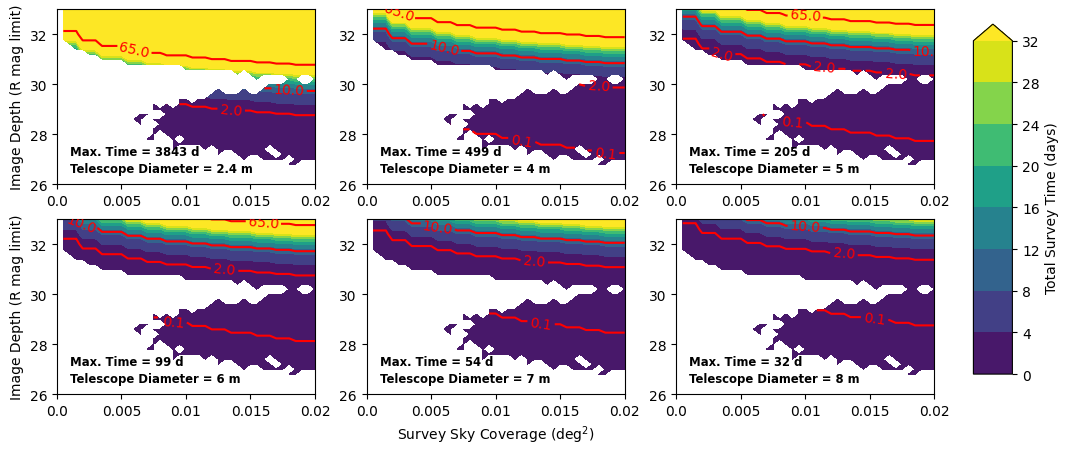

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(13, 5))
axs = axs.ravel()

for i in range(len(diameters)):
  times_D = np.where(good_ks >= 0.0, survey_time_matrix_o_D[i], float('nan'))
  cont = axs[i].contourf(survey_omega, survey_depth, times_D, levels=levels_D, extend='max')
  cont_lines = axs[i].contour(survey_omega, survey_depth, times_D, levels = [0.1, 2.0, 10, 65], colors = 'red')
  axs[i].clabel(cont_lines, inline=True, fontsize='medium')
  axs[i].xaxis.set_major_formatter('{x}')
  axs[i].locator_params(axis='x', nbins=4)
  if i == 0 or i ==3:
    axs[i].set_ylabel('Image Depth (R mag limit)')
  if i == 4:
    axs[i].set_xlabel('Survey Sky Coverage (deg$^{2}$)')
  title = 'Telescope Diameter = '+str(diameters[i])+' m'
  x = np.min(survey_omega) + (np.max(survey_omega) - np.min(survey_omega))*0.05
  y = np.min(survey_depth) + (np.max(survey_depth) - np.min(survey_depth))*0.05
  axs[i].text(x, y, title, color = 'black', horizontalalignment = 'left', verticalalignment = 'bottom', fontsize='small', fontweight='semibold')
  x = np.min(survey_omega) + (np.max(survey_omega) - np.min(survey_omega))*0.05
  y = np.min(survey_depth) + (np.max(survey_depth) - np.min(survey_depth))*0.15
  max_time = np.round(np.max(times_D[np.isfinite(times_D)]))
  axs[i].text(x, y, 'Max. Time = '+str(int(max_time))+' d', color = 'black', horizontalalignment = 'left', verticalalignment = 'bottom', fontsize='small', fontweight='semibold')
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.83, 0.15, 0.03, 0.7])
cb = plt.colorbar(cont, cax=cbar_ax)
cb.set_label(label='Total Survey Time (days)')
plt.savefig("kbo_panel2_plot2.pdf", bbox_inches='tight')
# files.download("kbo_panel2_plot2.pdf")
plt.show()

In [ ]:
t1 = 65.0     # Time for acceptable KBO survey in days with 2.4 m telescope
t2 = 2.0      # Time for acceptable KBO survey in days with 6.0 m telescope
hudf = 11.3   # Length of HUDF in days
min_hst_hudfs = round(65.0/hudf)
orb = 60.0    # Length of a typical HST orbit in minutes
min_hst_orb = np.ceil((t1 * 24.0 * 60.0)/orb)   # Minimum total survey time for 2.4 m telescope in units of 60 min orbits
min_EAC2_orb = np.ceil((t2 * 24.0 * 60.0)/orb)   # Minimum total survey time for 6.0 m telescope in units of 60 min orbits
print('HUDF time = '+str(hudf)+' days')
print('Minimum total survey time for 2.4 m = '+str(t1)+' days = '+str(min_hst_orb)+' orbits = '+str(min_hst_hudfs)+' HUDFs')
print('Minimum total survey time for 6.0 m = '+str(t2)+' days = '+str(min_EAC2_orb)+' orbits')

HUDF time = 11.3 days
Minimum total survey time for 2.4 m = 65.0 days = 1560.0 orbits = 6 HUDFs
Minimum total survey time for 6.0 m = 2.0 days = 48.0 orbits


**FINDING:** An acceptable KBO survey with HST would be equivalent to 6 Hubble Ultra-Deep Fields. With HWO EAC2, an acceptable KBO survey would be in the Small proposal class.
*   HUDF time = 11.3 days
*   Minimum total survey time for 2.4 m ~ 65 days ~ 1560 orbits ~ 6 HUDFs
*   Minimum total survey time for 6.0 m ~ 2 days ~ 48 orbits



**Plot 3: Survey Quality vs. Camera Field-of-View**

In [ ]:
fov_array = camera_fov*(np.arange(6)+1.0)
survey_time_matrix_o_FOV = np.zeros((len(fov_array), len(survey_depth), len(survey_omega)))

In [ ]:
for i in range(len(fov_array)):
  for j in range(len(survey_depth)):
    for k in range(len(survey_omega)):
      visits = np.ceil(survey_omega[k]/fov_array[i])
      survey_time_matrix_o_FOV[i,j,k] = image_time_matrix[j,k]*visits + (visits*overhead)/(24.*60.*60.)

In [ ]:
# Get contour levels to use for all plots
fig = plt.figure()
ax = fig.add_subplot(111)
i = np.where(fov_array == np.max(fov_array))[0][0]
times_fov = np.where(good_ks >= 0.0, survey_time_matrix_o_FOV[i], float('nan'))
cont = ax.contourf(survey_omega, survey_depth, times_fov)
levels_fov = cont.levels
plt.close(fig)

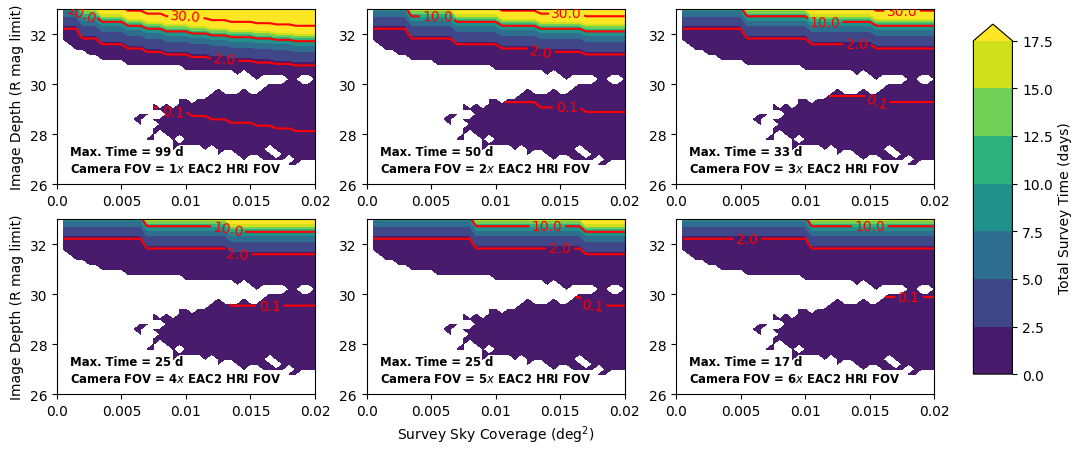

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(13, 5))
axs = axs.ravel()

for i in range(len(fov_array)):
  times_fov = np.where(good_ks >= 0.0, survey_time_matrix_o_FOV[i], float('nan'))
  axs[i].xaxis.set_major_formatter('{x}')
  axs[i].locator_params(axis='x', nbins=4)
  cont = axs[i].contourf(survey_omega, survey_depth, times_fov, levels=levels_fov, extend='max')
  cont_lines = axs[i].contour(survey_omega, survey_depth, times_fov, levels = [0.1, 2.0, 10, 30], colors = 'red')
  axs[i].clabel(cont_lines, inline=True, fontsize='medium')
  if i == 0 or i == 3 :
    axs[i].set_ylabel('Image Depth (R mag limit)')
  if i == 4:
    axs[i].set_xlabel('Survey Sky Coverage (deg$^{2}$)')
  title = 'Camera FOV = '+str(i+1)+'$x$ EAC2 HRI FOV'
  x = np.min(survey_omega) + (np.max(survey_omega) - np.min(survey_omega))*0.05
  y = np.min(survey_depth) + (np.max(survey_depth) - np.min(survey_depth))*0.05
  axs[i].text(x, y, title, color = 'black', horizontalalignment = 'left', verticalalignment = 'bottom', fontsize='small', fontweight='semibold')
  x = np.min(survey_omega) + (np.max(survey_omega) - np.min(survey_omega))*0.05
  y = np.min(survey_depth) + (np.max(survey_depth) - np.min(survey_depth))*0.15
  max_time = np.round(np.max(times_fov[np.isfinite(times_fov)]))
  axs[i].text(x, y, 'Max. Time = '+str(int(max_time))+' d', color = 'black', horizontalalignment = 'left', verticalalignment = 'bottom', fontsize='small', fontweight='semibold')
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.83, 0.15, 0.03, 0.7])
cb = plt.colorbar(cont, cax=cbar_ax)
cb.set_label(label='Total Survey Time (days)')
plt.savefig("kbo_panel2_plot3.pdf", bbox_inches='tight')
# files.download("kbo_panel2_plot3.pdf")
plt.show()

**FINDING:** Total time for acceptable survey is $\propto FOV^{-1}$ (no surprise there).

# Set final survey parameters
**Enabling:** A survey that can distinguish between the two power laws at 99.7% confidence ($3\sigma$).

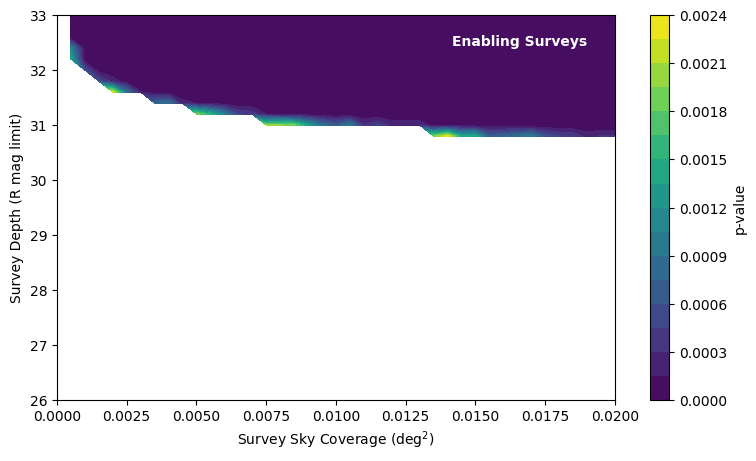

In [ ]:
tmplev = cont_plot(survey_depth, survey_omega, very_good_ks, title = 'Enabling Surveys')

In [ ]:
# Limits of region where contours are well-behaved
p = np.where(very_good_omega == np.min(very_good_omega))
omega_lim = np.min(very_good_omega[p])
depth_lim = np.min(very_good_depth[p])
print('Minimum sky coverage: '+str(omega_lim))
print('Minimum depth: '+str(depth_lim))

Minimum sky coverage: 0.0005
Minimum depth: 32.2


**FINDING:** Total time for acceptable survey is approximately $\propto D^{-4} FOV^{-1}$. This scaling relation is only valid for depth $\mathrm{R_{lim}} \gtrsim 32.2$ and sky coverage $\Omega \gtrsim 0.0005$ deg$^{2}$. Surprise!

**Choose to go deep and push down to smaller KBOs, thereby also facilitating KBO binarity studies.**

In [ ]:
# Choose fewest number of visits allowable
r = np.where(very_good_omega >= camera_fov)
tmp_final_omega = np.min(very_good_omega[r])
s = np.where(very_good_omega == tmp_final_omega)
final_depth = np.min(very_good_depth[s])
print('Final depth (R mag): '+str(final_depth))
final_visits = np.ceil(tmp_final_omega/camera_fov)
print('Number of images: '+str(final_visits))
final_omega = np.round(camera_fov*final_visits, decimals=4)
print('Final sky coverage: '+str(final_omega)+' sq. deg')

Final depth (R mag): 31.6
Number of images: 2.0
Final sky coverage: 0.0033 sq. deg


In [ ]:
final_size = np.round(mag_to_km(final_depth), decimals=1)
print('Smallest KBO diameter: '+str(final_size)+' km')

Smallest KBO diameter: 3.8 km


In [ ]:
exptime, hri = camera_exptime3('EAC2', 'G2V Star', final_depth, SNR, silent=True)                 # Exposure time per image in seconds
final_time = np.ceil((np.array(visits*exptime[Rband_index]) + visits*overhead)/(24.0*60.0*60.0))
print(' ')
print('Final total survey time: '+str(final_time)+' days')

 
Final total survey time: 2.0 days


**Dictionary with final survey parameters**

In [ ]:
final_survey = {'Band': 'R', 'depth': final_depth, 'min_size': final_size, 'size_unit': 'km', 'omega': final_omega, 'omega_unit': 'sq. deg', 'time': final_time, 'time_unit': 'days'}
api.register_chosen_parameters(final_survey)

**Compare to non-optimized LUVOIR-B Survey Parameters**

R$_\mathrm{lim}$ = 31.5 and $\Omega = 0.017$ deg$^{2}$ = 146 days.

In [ ]:
depth_luvoir = 31.5   # Limiting R band magnitude
omega_luvoir = 0.017  # Survey sky coverage in sq. deg.
time_luvoir = 146     # Total survey time in days

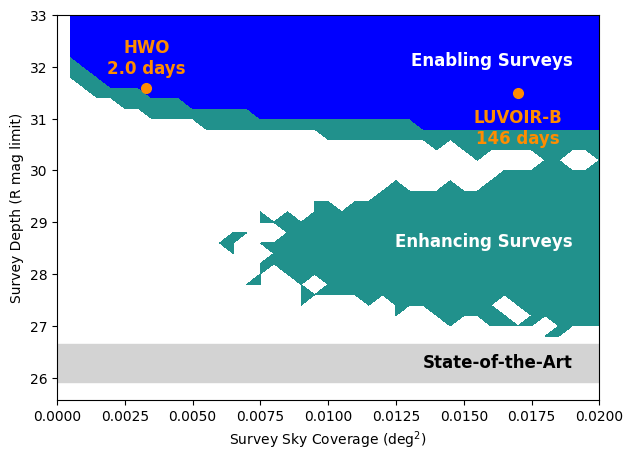

In [ ]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111)
ax.set_xlabel('Survey Sky Coverage (deg$^{2}$)')
ax.set_ylabel('Survey Depth (R mag limit)')
cont95 = ax.contourf(survey_omega, survey_depth, good_ks, levels=[0.0, 1 - conf1])
cont99 = ax.contourf(survey_omega, survey_depth, very_good_ks, colors = ['blue'], levels=[0.0, 1 - conf2])
x1 = np.max(survey_omega) - (np.max(survey_omega) - np.min(survey_omega))*0.05
y1 = np.max(survey_depth) - (np.max(survey_depth) - np.min(survey_depth))*0.60
title1='Enhancing Surveys'
ax.text(x1, y1, title1, color = 'white', horizontalalignment = 'right', verticalalignment = 'top', fontsize='large', fontweight='semibold')
y2 = np.max(survey_depth) - (np.max(survey_depth) - np.min(survey_depth))*0.10
title2='Enabling Surveys'
ax.text(x1, y2, title2, color = 'white', horizontalalignment = 'right', verticalalignment = 'top', fontsize='large', fontweight='semibold')
ax.axhspan(25.92, 26.65, color='lightgrey')
y3 = np.max(survey_depth) - (np.max(survey_depth) - np.min(survey_depth))*0.93
title3='State-of-the-Art'
# DEEP survey magnitude limits
ax.text(x1, (26.65 - 25.92)/2. + 25.92, title3, color = 'black', horizontalalignment = 'right', verticalalignment = 'center', fontsize='large', fontweight='semibold')
plt.plot(final_omega, final_depth, 'o', color = 'darkorange', markersize=7)
ax.text(final_omega, final_depth+0.2, 'HWO\n'+str(final_time)+' days', color = 'darkorange', horizontalalignment = 'center', verticalalignment = 'bottom', fontsize='large', fontweight='semibold')
plt.plot(omega_luvoir, depth_luvoir, 'o', color = 'darkorange', markersize=7)
ax.text(omega_luvoir, depth_luvoir-0.3, 'LUVOIR-B\n'+str(time_luvoir)+' days', color = 'darkorange', horizontalalignment = 'center', verticalalignment = 'top', fontsize='large', fontweight='semibold')
plt.savefig("kbo_panel1_plot3.pdf", bbox_inches='tight')
# files.download("kbo_panel1_plot3.pdf")
plt.show()

# Next Steps

*   Prepare to integrate these results with other modules.
*   Increase fidelity by testing recovery of SNR goal using tracking speed approach and shift-and-stack approach.



# Observatory Capability vs. Engineering Challenge (Panel 3)